In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import h5py
import json
import pickle
import os
import shap
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


In [10]:
class CFG:
    colab = False  # Cambiar a True si se usa Colab
    Root = '..' if not colab else '/content/drive/MyDrive/PAI'
    path_df_imputed = f'{Root}/BaseDatos/df_imputed_with_original.csv'
    path_df_imputed_corrected = f'{Root}/BaseDatos/df_imputed_corrected.csv'
    elements_list = ["Nitrogen", "Phosphorus", "Potassium"]
    productivity_vars = ["Plant_Height (cm)", "Number of Flowers", 'Number of Harvested Fruits', 
                         'Weight of Harvested Fruits (Kg)','Fruit Height (mm)', 'Fruit Diameter (mm)']
    model_list = ['RF', 'SVM', 'MLP', 'KNN']
    include_prod = False  # Para incluir variables de productividad


    # NOTE: Cambiar el siguiente flag segun el tipo de entrenamiento
    individual_train = False # Para entrenar con los elementos por separado
    cuartiles_train = True

    # NOTE: Cambiar el siguiente path segun include prod
    if include_prod:
        if cuartiles_train:
            class_path = f'{Root}/Resultados/classification_cuartiles_include_prod/'
        else:
            class_path = f'{Root}/Resultados/classification_include_prod/'
    else:
        if cuartiles_train:
            class_path = f'{Root}/Resultados/classification_cuartiles_exclude_prod/'
        else:
            class_path = f'{Root}/Resultados/classification_exclude_prod/'


    if individual_train:
        path_pkl_results_classification = f"{class_path}class_results_individual_elements.pkl"
    elif cuartiles_train:
        path_pkl_results_classification = f"{class_path}class_models_cuartiles.pkl"
    else:
        path_pkl_results_classification = f"{class_path}all_classification_models.pkl"

    treat_quantiles_path = f'{Root}/Resultados/treatments_quantile_unified.json'

In [3]:
def plot_correlation_productivity(df_filtered, available_important_vars, productivity_vars):
    """
    Genera gráficos de dispersión para analizar la correlación entre variables importantes y de productividad.
    
    Args:
        df_filtered (pd.DataFrame): DataFrame filtrado sin ceros en variables de productividad.
        available_important_vars (list): Lista de variables importantes disponibles.
        productivity_vars (list): Lista de variables de productividad.
    """
    # Calcular matriz de correlación
    correlation_data = df_filtered[available_important_vars + productivity_vars]

    # Calcular correlaciones entre variables importantes y productividad
    corr_matrix = correlation_data.corr() #por default pearson

    # Extraer solo las correlaciones entre variables importantes y productividad
    corr_with_productivity = corr_matrix.loc[available_important_vars, productivity_vars]

    # Visualizar matriz de correlación
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(corr_with_productivity, annot=True, fmt='.3f', cmap='RdBu_r', 
                center=0, vmin=-1, vmax=1, linewidths=0.5,
                cbar_kws={'label': 'Correlation Coefficient'})
    ax.set_title('Correlation: Important Variables vs Productivity Variables', 
                fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Productivity Variables', fontsize=12)
    ax.set_ylabel('Important Variables', fontsize=12)
    plt.tight_layout()
    plt.show()

    # Mostrar las correlaciones más fuertes
    print("CORRELACIONES MÁS FUERTES CON PRODUCTIVIDAD")

    for prod_var in productivity_vars:
        print(f"\n{prod_var}:")
        correlations = corr_with_productivity[prod_var].abs().sort_values(ascending=False)
        for var, corr_val in correlations.head(5).items():
            actual_corr = corr_with_productivity.loc[var, prod_var]
            print(f"  {var}: {actual_corr:.3f}")

## 1. TOP Variables Más Frecuentes

## 1.1 . Funciones

In [7]:
def analyze_top_variables(csv_path):
    """
    Analiza las variables más frecuentes en el top N de diferentes modelos.
    
    Args:
        csv_path (str): Ruta al archivo CSV con las variables ordenadas por importancia.
        El formato del csv debe ser del tipo:
            Model1, Model2, Model3, ...
            var1,   var2,   var3, ...
            var4,   var5,   var6, ...
            ...
    
    Returns:
        tuple: (DataFrame con frecuencias, DataFrame con posiciones)
    """
    # Leer el CSV
    df = pd.read_csv(csv_path)
    
    # Diccionario para almacenar la frecuencia de cada variable
    variable_frequency = {}
    # Diccionario para almacenar las posiciones de cada variable
    variable_positions = {}
    
    # Iterar sobre cada columna (cada modelo/clase)
    for col in df.columns:
        # Obtener las top N variables de esta columna
        top_vars = df[col].tolist()
        
        # Contar frecuencia y registrar posiciones
        for position, var in enumerate(top_vars, start=1):
            if var not in variable_frequency:
                variable_frequency[var] = 0
                variable_positions[var] = []
            
            variable_frequency[var] += 1
            variable_positions[var].append({
                'model_class': col,
                'position': position
            })
    
    # Crear DataFrame con frecuencias
    freq_df = pd.DataFrame(list(variable_frequency.items()), 
                          columns=['Variable', 'Frequency'])
    freq_df = freq_df.sort_values('Frequency', ascending=False).reset_index(drop=True)
    
    # Crear DataFrame con posiciones detalladas
    position_data = []
    for var, positions in variable_positions.items():
        for pos_info in positions:
            position_data.append({
                'Variable': var,
                'Model_Class': pos_info['model_class'],
                'Position': pos_info['position'],
                'Frequency': variable_frequency[var]
            })
    
    position_df = pd.DataFrame(position_data)
    
    return freq_df, position_df


def plot_top_variables_analysis(freq_df, element=None, percentage=80, dir_path=None):
    """
    Genera gráficos para visualizar el análisis de variables top.
    
    Args:
        freq_df (pd.DataFrame): DataFrame con frecuencias de variables.
        position_df (pd.DataFrame): DataFrame con posiciones detalladas.
        top_variables (int): Número de variables principales a visualizar.
    """
    
    # Crear figura con subplots
    #crear copia para no modificar el original
    freq_df_copy = freq_df.copy()
    # Cambiar "_" por " " en nombres de variables para mejor visualización
    freq_df_copy['Variable'] = freq_df_copy['Variable'].str.replace('_', ' ')
    freq_df_copy['Variable'] = freq_df_copy['Variable'].str.replace('[', ' [')
    #Gráfico de barras: Frecuencia de aparición en top
    
    sns.barplot(data=freq_df_copy, 
                x='Frequency', y='Variable', hue='Variable', palette='viridis', legend=False)
    
    plt.title(f'Variables Most Frequent - {element} Model', fontsize=14, fontweight='bold')
    plt.xlabel(f'Frequency (times appearing in {percentage}%)', fontsize=12)
    plt.ylabel('Variable', fontsize=12)
    plt.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(dir_path + f'top_vars_freq_{percentage}_{element}.png', dpi=300)
    plt.show()

def most_frequent_variables_analysis(csv_path, element=None, percentage=80, dir_path=None):
    """
    Realiza el análisis de las variables más frecuentes de diferentes modelos.
    
    Args:
        csv_path (str): Ruta al archivo CSV con las variables ordenadas por importancia.
        element (str): Nombre del elemento (opcional).
        percentage (int): Porcentaje para definir (por defecto 80).
        dir_path (str): Ruta del directorio para guardar los gráficos (opcional).
    Returns:
        list: Lista de variables que aparecen en todos los modelos.
    """

    top_vars_freq, top_vars_positions = analyze_top_variables(csv_path)

    #-------------------------------------
    ## Sumar posiciones para cada variable
    position_summary = top_vars_positions.groupby('Variable', as_index=False).agg({
        'Position': 'sum',
        'Frequency': 'first'  # o 'max' ya que todos tienen el mismo valor
    }).rename(columns={'Position': 'Position_Sum'})

    # Ordenar por Frequency y Position_Sum
    position_summary = position_summary.sort_values(
                    by=['Frequency', 'Position_Sum'], 
                    ascending=[False, True]  
                    ).reset_index(drop=True)
    #display(position_summary)
    #-------------------------------------
    #display(top_vars_freq)

    # Generar gráfico de barras de las variables más frecuentes
    plot_top_variables_analysis(position_summary, 
                                              element=element,
                                              percentage=percentage,
                                              dir_path=dir_path)
    all_models_count = len(pd.read_csv(csv_path).columns)
    return position_summary[position_summary['Frequency'] == all_models_count]['Variable'].tolist()
    



## 1.2 Vars más importantes presentes en TODOS los algoritmos - 3-Clases

Se espera que se lea un csv que contenga el siguiente estilo:

Model1, Model2, Model3, ...

var1,   var2,   var3, ...

var4,   var5,   var6, ...

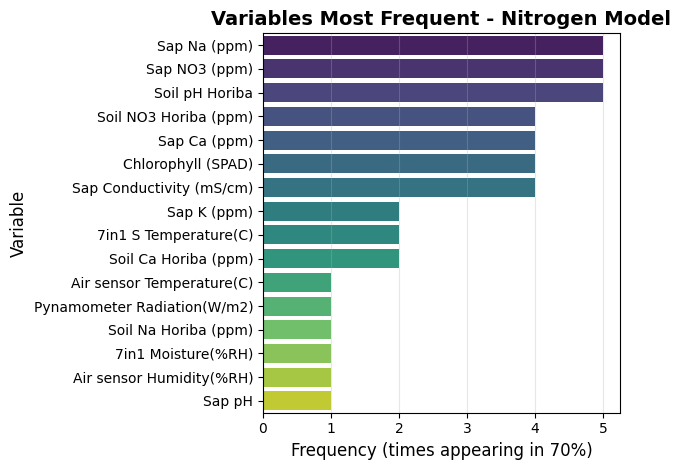

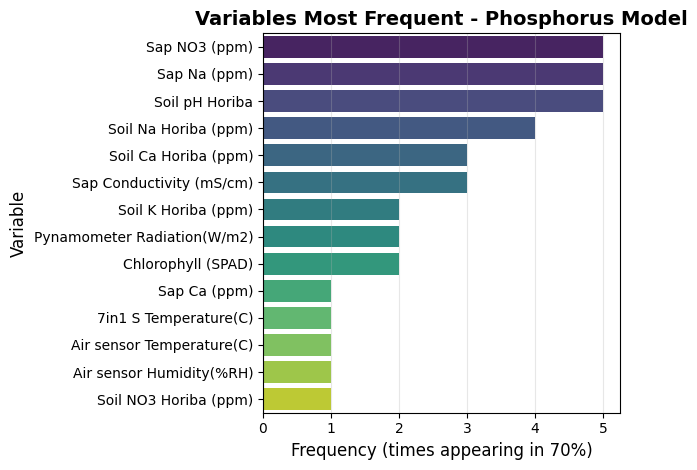

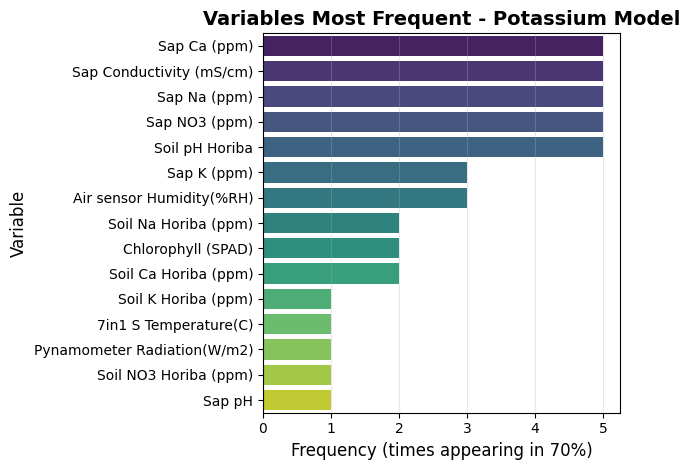

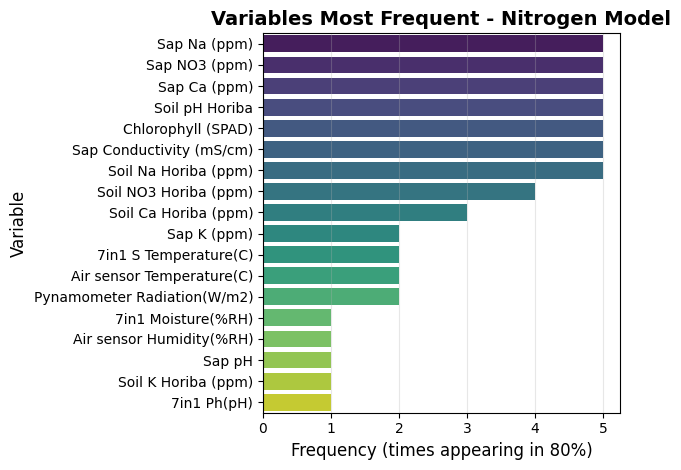

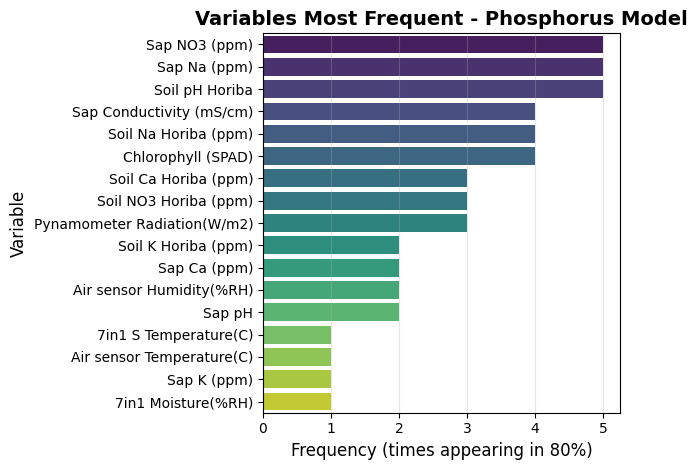

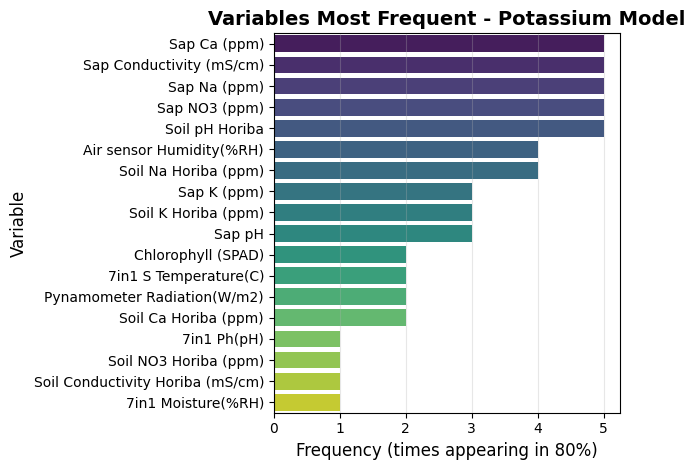

In [9]:

dir_path = CFG.class_path + 'permutation_importance/'
if CFG.individual_train:
    percentages = [70,80]
    for percentage in percentages:
        variables_element = {}
        for element in ['Nitrogen', 'Phosphorus', 'Potassium']:
            # Ruta de variables más importantes en cada algoritmo
            #csv_path = f"{CFG.class_path}best_{percentage}_percent_features_weight_3_{element}.csv"
            csv_path = f"{dir_path}best_{percentage}_percent_features_{element}.csv"
            # Obtener las más importantes ponderadas. Para el modelo específico
            vars = most_frequent_variables_analysis(csv_path, 
                                                    element=element, 
                                                    percentage=percentage,
                                                    dir_path=dir_path)
            variables_element[element] = vars

        # Guardar como JSON
        with open(f"{dir_path}" + f'most_frequent_variables_{percentage}.json', 'w') as f:
            json.dump(variables_element, f, indent=4)

        # guardar en dataframe csv
        df_vars = pd.DataFrame.from_dict(variables_element, orient='index').transpose()
        df_vars.to_csv(dir_path + f'most_frequent_variables_TOTAL_{percentage}.csv', index=False)

## 1.3 Vars más importantes presentes en TODOS los algoritmos - 2-Clases (Cuartiles)

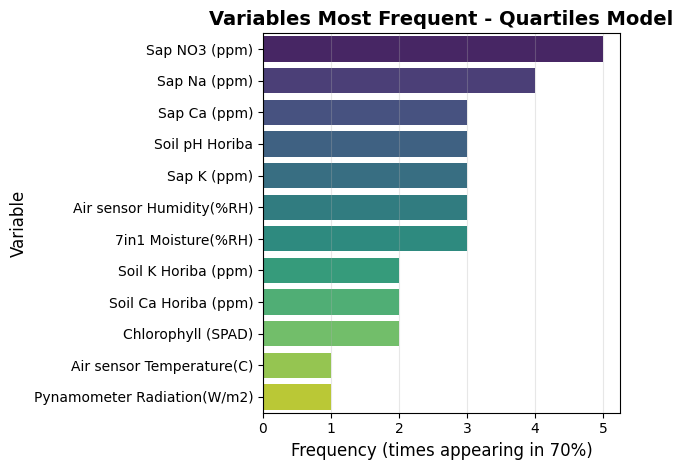

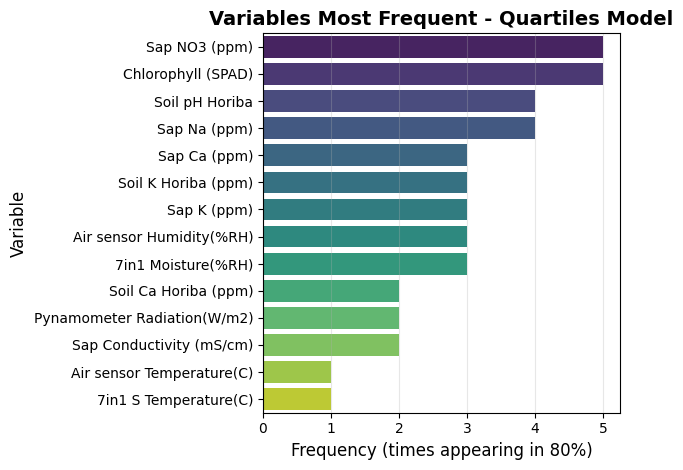

In [11]:
dir_path = CFG.class_path + 'permutation_importance/'

if CFG.cuartiles_train:
    percentages = [70,80]
    for percentage in percentages:
        variables_element = {}
    
        # Ruta de variables más importantes en cada algoritmo
        #csv_path = f"{CFG.class_path}best_{percentage}_percent_features_weight_2_Quartiles.csv"
        csv_path = f"{dir_path}best_{percentage}_percent_features_Quartiles.csv"
        # Obtener las más importantes ponderadas. Para el modelo específico
        vars = most_frequent_variables_analysis(csv_path, 
                                                element='Quartiles', 
                                                percentage=percentage,
                                                dir_path=dir_path)
        variables_element['Quartiles'] = vars

        # Guardar como JSON
        with open(f'{dir_path}most_frequent_variables_{percentage}.json', 'w') as f:
            json.dump(variables_element, f, indent=4)

        # guardar en dataframe csv
        df_vars = pd.DataFrame.from_dict(variables_element, orient='index').transpose()
        df_vars.to_csv(f'{dir_path}most_frequent_variables_TOTAL_{percentage}.csv', index=False)

In [7]:
import pandas as pd

df = pd.read_csv(f'{CFG.class_path}most_frequent_variables_TOTAL_80.csv')

variables_en_todas = []
for var in set(df.values.flatten()):
    if pd.notna(var) and all(var in df[col].values for col in df.columns):
        variables_en_todas.append(var)

pos_dict = {}
for var in variables_en_todas:
    posiciones = {col: df[df[col] == var].index[0] for col in df.columns}
    pos_dict[var] = posiciones

result = pd.DataFrame(variables_en_todas, columns=['Variable'])
result['Posiciones'] = result['Variable'].map(pos_dict)
result['Suma_Posiciones'] = result['Posiciones'].apply(lambda x: sum(x.values()))
result = result.sort_values('Suma_Posiciones').reset_index(drop=True)
result

,Variable,Posiciones,Suma_Posiciones
0,Sap Conductivity (mS/cm),"{'Nitrogen': 2, 'Phosphorus': 2, 'Potassium': 0}",4
1,Sap Na (ppm),"{'Nitrogen': 0, 'Phosphorus': 4, 'Potassium': 2}",6
2,Sap NO3 (ppm),"{'Nitrogen': 6, 'Phosphorus': 0, 'Potassium': 4}",10
3,Soil pH Horiba,"{'Nitrogen': 3, 'Phosphorus': 5, 'Potassium': 3}",11


In [8]:
list(pd.Series(df.values.flatten()).dropna().unique())

['Sap Na (ppm)',
 'Sap NO3 (ppm)',
 'Sap Conductivity (mS/cm)',
 'Soil NO3 Horiba (ppm)',
 'Soil Ca Horiba (ppm)',
 'Sap Ca (ppm)',
 'Soil pH Horiba',
 'Air_sensor_Humidity(%RH)',
 'Chlorophyll (SPAD)',
 '7in1_S_Temperature(C)',
 'Sap pH',
 '7in1_Ph(pH)',
 'Pynamometer_Radiation(W/m2)']

## 2. Relación entre variables más importantes y productividad

### Cagar Base de datos

In [82]:
# df_imputed = pd.read_csv(CFG.path_df_imputed_corrected)
# df_imputed.columns

### Visualización de Variables Más Importantes

In [83]:
# # Definir variables de productividad
# productivity_vars = [
#     "Number of Harvested Fruits", 
#     "Weight of Harvested Fruits (Kg)",
#     "Fruit Height (mm)", 
#     "Fruit Diameter (mm)"
# ]
# top_important_vars = top_vars_freq.head(10)['Variable'].tolist()
# available_important_vars = [var for var in top_important_vars if var in df_imputed.columns]

In [84]:
# #grafico boxplot de las variables importantes disponibles
# def plot_boxplots(df, variables):
#     from plotly.subplots import make_subplots
    
#     ncols = 4
#     nrows = (len(variables) + ncols - 1) // ncols  # Redondear hacia arriba
    
#     fig = make_subplots(
#         rows=nrows, 
#         cols=ncols,
#         subplot_titles=[var.replace('_', ' ') for var in variables],
#         vertical_spacing=0.08,
#         horizontal_spacing=0.05
#     )
    
#     for i, var in enumerate(variables):
#         row = i // ncols + 1
#         col = i % ncols + 1
        
#         fig.add_trace(
#             go.Box(y=df[var], name=var, showlegend=False),
#             row=row, col=col
#         )
        
#         fig.update_yaxes(title_text=var.replace('_', ' '), row=row, col=col)
    
#     fig.update_layout(
#         height=400 * nrows,
#         width=1400,
#         title_text="Boxplots of Variables",
#         title_font_size=16,
#         showlegend=False
#     )
    
#     fig.show()
# def plot_variables_histogram(df, variables):
#     fig, axes = plt.subplots(nrows=4, ncols=len(variables)//4 + 1, figsize=(20, 20))
#     axes = axes.flatten()
#     sns.set_style("whitegrid")
#     for i, var in enumerate(variables):
#         if i >= len(axes):
#             break

#         sns.histplot(df[var], bins=30, kde=True, ax=axes[i])
#         axes[i].set_title(f'Histogram of {var}', fontsize=14)
#         axes[i].set_xlabel(var.replace('_', ' '), fontsize=12)
#         axes[i].set_ylabel('Frequency', fontsize=12)

### 2. Cuartiles de Variables 

In [85]:
# plot_boxplots(df_imputed, available_important_vars + productivity_vars)

In [86]:
# plot_variables_histogram(df_imputed, available_important_vars + productivity_vars)

### 3. Relación con Variables de Productividad

In [87]:
# for var in available_important_vars:
#     plt.figure(figsize=(10, 6))
#     sns.scatterplot(data=df_imputed,
#                     x='Weight of Harvested Fruits (Kg)',
#                     y=var,
#                     hue='Treatment_Num', alpha=0.6)
#     plt.show()

In [88]:
# #carpeta para guardar los gráficos
# output_dir = "../Resultados/classification/Productivity_Scatter_Plots/"
# os.makedirs(output_dir, exist_ok=True)
# # Scatter plots interactivos con Plotly
# for var in available_important_vars:
#     fig = px.scatter(
#         df_imputed,
#         x='Weight of Harvested Fruits (Kg)',
#         y=var,
#         color='Treatment_Num',
#         title=f'Interactive Scatter Plot: {var} vs Number of Harvested Fruits',
#         labels={
#             'Number of Harvested Fruits': 'Number of Harvested Fruits',
#             var: var.replace('_', ' '),
#             'Treatment_Num': 'Treatment Number'
#         },
#         hover_data={
#             'Treatment_Num': True,  # Mostrar Treatment_Num
#             'Number of Harvested Fruits': ':.2f',  # Formato con 2 decimales
#             var: ':.2f'  # Formato con 2 decimales
#         },
#         opacity=0.6,
#         height=600,
#         width=1000
#     )
    
#     # Personalizar el diseño
#     fig.update_layout(
#         hovermode='closest',
#         font=dict(size=12)
#     )

#     # Guardar figura
#     fig.write_html(f"{output_dir}scatter_{var.replace('/', '_')}_vs_Number_of_Harvested_Fruits.html")
    
#     fig.show()

### 3.1 Preparar datos y filtrar

* Eliminar datos iguales a 0
* Seleccionar variables de productividad

In [89]:
# # Definir variables de productividad
# productivity_vars = [
#     "Number of Harvested Fruits", 
#     "Weight of Harvested Fruits (Kg)",
#     "Fruit Height (mm)", 
#     "Fruit Diameter (mm)"
# ]

# # Filtrar filas donde ninguna variable de productividad sea cero
# df_filtered = df_imputed.copy()
# for var in productivity_vars:
#     if var in df_filtered.columns:
#         df_filtered = df_filtered[df_filtered[var] > 0]

# print(f"Datos originales: {len(df_imputed)} filas")
# print(f"Datos filtrados (sin ceros en productividad): {len(df_filtered)} filas")
# print(f"Filas eliminadas: {len(df_imputed) - len(df_filtered)}")

# # Obtener las variables más importantes del análisis anterior
# top_important_vars = top_vars_freq.head(10)['Variable'].tolist()
# print(f"\nTop 10 variables más importantes:")
# for i, var in enumerate(top_important_vars, 1):
#     print(f"  {i}. {var}")

# # Verificar qué variables están disponibles en el dataframe
# available_important_vars = [var for var in top_important_vars if var in df_filtered.columns]
# print(f"\nVariables importantes disponibles en la base de datos: {len(available_important_vars)}/{len(top_important_vars)}")

# df_filtered.head()

### 3.2 Análisis de Correlación en Datos Limpios (excluir Registros de 0)

In [90]:
# plot_correlation_productivity(df_filtered, available_important_vars, productivity_vars)

### 3.1.1. Grafico BoxPlot (Datos Filtrados)

In [91]:
# #extraer mediana de productividad
# median_productivity = df_filtered['Weight of Harvested Fruits (Kg)'].median()

# umbral_productivity = 0.6
# print(f"\nMediana de 'Weight of Harvested Fruits (Kg)': {median_productivity:.2f} Kg")
# #filtrar datos que pasen ese umbral
# df_high_productivity = df_filtered[df_filtered['Weight of Harvested Fruits (Kg)'] >= umbral_productivity]
# df_low_productivity = df_filtered[df_filtered['Weight of Harvested Fruits (Kg)'] < umbral_productivity]
# print(f"Alta productividad: {len(df_high_productivity)} muestras")
# print(f"Baja productividad: {len(df_low_productivity)} muestras")

# # Combinar variables importantes y de productividad
# all_vars_to_plot = available_important_vars + productivity_vars

# # Crear figura con dropdown
# fig = go.Figure()

# # Agregar trazas para cada variable (inicialmente ocultas excepto la primera)
# for i, var in enumerate(all_vars_to_plot):
#     # Alta productividad
#     fig.add_trace(go.Box(
#         y=df_high_productivity[var],
#         name='High Productivity',
#         marker_color='lightgreen',
#         visible=(i == 0),  # Solo la primera variable visible al inicio
#         legendgroup='high',
#         showlegend=True
#     ))
    
#     # Baja productividad
#     fig.add_trace(go.Box(
#         y=df_low_productivity[var],
#         name='Low Productivity',
#         marker_color='lightcoral',
#         visible=(i == 0),  # Solo la primera variable visible al inicio
#         legendgroup='low',
#         showlegend=True
#     ))

# # Crear botones para el dropdown
# buttons = []
# for i, var in enumerate(all_vars_to_plot):
#     # Calcular estadísticas para la variable actual
#     var_min = df_filtered[var].min()
#     var_max = df_filtered[var].max()
#     high_min = df_high_productivity[var].min()
#     high_max = df_high_productivity[var].max()
#     high_median = df_high_productivity[var].median()
#     low_min = df_low_productivity[var].min()
#     low_max = df_low_productivity[var].max()
#     low_median = df_low_productivity[var].median()
    
#     # Crear texto con estadísticas
#     stats_text = (
#         f"<b>High Productivity:</b> Range [{high_min:.2f} - {high_max:.2f}] | Median: {high_median:.2f}<br>"
#         f"<b>Low Productivity:</b> Range [{low_min:.2f} - {low_max:.2f}] | Median: {low_median:.2f}<br>"
#         f"<b>Samples:</b> High: {len(df_high_productivity)} | Low: {len(df_low_productivity)}"
#     )
    
#     # Crear lista de visibilidad: cada variable tiene 2 trazas (high y low)
#     visible = [False] * (len(all_vars_to_plot) * 2)
#     visible[i * 2] = True      # Alta productividad
#     visible[i * 2 + 1] = True  # Baja productividad
    
#     buttons.append(dict(
#         label=var,
#         method='update',
#         args=[
#             {'visible': visible},
#             {
#                 'title': f'{var} by Productivity Level',
#                 'yaxis': {'title': var, 'range': [var_min * 0.95, var_max * 1.05]},
#                 'annotations': [{
#                     'text': stats_text,
#                     'xref': 'paper',
#                     'yref': 'paper',
#                     'x': 0.5,
#                     'y': -0.15,
#                     'xanchor': 'center',
#                     'yanchor': 'top',
#                     'showarrow': False,
#                     'font': {'size': 11, 'color': '#444'},
#                     'bgcolor': 'rgba(255, 255, 255, 0.9)',
#                     'bordercolor': '#ccc',
#                     'borderwidth': 1,
#                     'borderpad': 8
#                 }]
#             }
#         ]
#     ))

# # Crear anotación inicial para la primera variable
# initial_var = all_vars_to_plot[0]
# high_min_init = df_high_productivity[initial_var].min()
# high_max_init = df_high_productivity[initial_var].max()
# high_median_init = df_high_productivity[initial_var].median()
# low_min_init = df_low_productivity[initial_var].min()
# low_max_init = df_low_productivity[initial_var].max()
# low_median_init = df_low_productivity[initial_var].median()

# initial_stats_text = (
#     f"<b>High Productivity:</b> Range [{high_min_init:.2f} - {high_max_init:.2f}] | Median: {high_median_init:.2f}<br>"
#     f"<b>Low Productivity:</b> Range [{low_min_init:.2f} - {low_max_init:.2f}] | Median: {low_median_init:.2f}<br>"
#     f"<b>Samples:</b> High: {len(df_high_productivity)} | Low: {len(df_low_productivity)}"
# )

# # Actualizar layout con dropdown
# fig.update_layout(
#     updatemenus=[
#         dict(
#             active=0,
#             buttons=buttons,
#             direction='down',
#             pad={'r': 10, 't': 10},
#             showactive=True,
#             x=0.11,
#             xanchor='left',
#             y=1.15,
#             yanchor='top'
#         )
#     ],
#     title=f'{all_vars_to_plot[0]} by Productivity Level - Umbral {umbral_productivity}Kg',
#     yaxis_title=all_vars_to_plot[0],
#     xaxis_title='Productivity Level',
#     height=650,
#     width=900,
#     showlegend=True,
#     hovermode='closest',
#     font=dict(size=12),
#     margin=dict(b=120),  # Aumentar margen inferior para el texto
#     annotations=[{
#         'text': initial_stats_text,
#         'xref': 'paper',
#         'yref': 'paper',
#         'x': 0.5,
#         'y': -0.15,
#         'xanchor': 'center',
#         'yanchor': 'top',
#         'showarrow': False,
#         'font': {'size': 11, 'color': '#444'},
#         'bgcolor': 'rgba(255, 255, 255, 0.9)',
#         'bordercolor': '#ccc',
#         'borderwidth': 1,
#         'borderpad': 8
#     }]
# )

# fig.show()

In [92]:
# df_filtered['Treatment_Num'].value_counts() \
#     .plot(kind='bar', figsize=(10, 6), color='skyblue')
# plt.title('Distribution of Treatment_Num in Filtered Data', fontsize=14, fontweight='bold')
# plt.xlabel('Treatment_Num', fontsize=12)
# plt.ylabel('Count', fontsize=12)
# plt.show()

In [93]:
# # hacer ranking de los tratamientos para productividad alta y baja
# treatment_productivity = df_filtered.groupby('Treatment_Num')['Weight of Harvested Fruits (Kg)'].median().reset_index()
# treatment_productivity = treatment_productivity.sort_values(by='Weight of Harvested Fruits (Kg)', ascending=False).reset_index(drop=True)
# print("\nRanking de Tratamientos por Productividad (mediana de Weight of Harvested Fruits (Kg)):")
# for i, row in treatment_productivity.iterrows():
#     print(f"  {i+1}. Treatment {int(row['Treatment_Num'])}: {row['Weight of Harvested Fruits (Kg)']:.2f} Kg")   

### 3.3 ¿Qué porcentaje de Muestras se relacionan con una productividad alta?

In [94]:
# # 1. Umbral de productividad alta
# median_productivity = df_filtered['Weight of Harvested Fruits (Kg)'].median()

# umbral = median_productivity

# #2. Calcular la cantidad de observaciones que están por encima de dicho umbral.
# # TODO: ¿cómo tener en cuenta que dichas mediciones se hacen en diferentes fechas?
# # ¿Revisar en una fecha específica (por ej última fecha registrada para todos los tratamientos)
# # la cantidad de registros que superan el umbral?
# print(median_productivity)
# print(len(df_filtered))
# print((df_filtered['Weight of Harvested Fruits (Kg)'] > umbral).sum())  # Cantidad de observaciones por encima del umbral
# print((df_filtered['Weight of Harvested Fruits (Kg)'] > umbral).sum()/len(df_filtered))  # Porcentaje de observaciones por encima del umbral

#### Revisando ultimas fechas para comparar la producción

In [95]:
# # 1. Unir las columnas de tiempo
# df_filtered['Date'] = pd.to_datetime(df_filtered[['Year', 'Month', 'Day']])

In [96]:
# fecha_umbral = '2024-11-01'
# df_filtered[((df_filtered['Date'] > pd.to_datetime(fecha_umbral)) & (df_filtered['Weight of Harvested Fruits (Kg)'] > umbral))]

In [97]:
# # Organizar por fecha
# df_filtered_date_sorted =df_imputed.copy()
# df_filtered_date_sorted['Date'] = pd.to_datetime(df_filtered_date_sorted[['Year', 'Month', 'Day']])
# df_filtered_date_sorted = df_filtered_date_sorted.sort_values(by=['Date'])
# # Hacer una sumatoria de furtos cosechados por tratamiento en total
# df_filtered_date_sorted.groupby('Treatment_Num')['Weight of Harvested Fruits (Kg)'].sum().reset_index()

### 4. Revisión de Tratamiento vs Productividad

#### 4.1 Datos Imputados

In [98]:
# df_filtered_date_sorted['Count_treatment'] = df_filtered_date_sorted.\
#     groupby('Treatment_Num').cumcount() + 1


# df_filtered_date_sorted.groupby('Treatment_Num', as_index=False).agg(
#     total_harvested=('Number of Harvested Fruits', 'sum'),
#     n_records=('Count_treatment', 'max')
# ).sort_values('total_harvested', ascending=False)

#### 4.2 Datos Raw (Manual + Movil)

In [99]:
# # Load Unified data
# df_unified = pd.read_csv(R"..\BaseDatos\BD Quindio unificados\Quindio_Movil_Manual_unificado.csv")
# df_unified['Treatment_Num'] = df_unified['Tratamiento'].str.extract(r'T(\d+)').astype(float)

# # Hacer columna de conteo del registro de tratamientos
# df_unified['Count_treatment'] = df_unified.groupby('Treatment_Num').cumcount() + 1

# mapeo = {
#     "Altura planta (cm)": "Plant_Height (cm)",
#     "Clorofila (SPAD)": "Chlorophyll (SPAD)",
#     "Numero flores ": "Number of Flowers",
#     "Numero frutos cosechados ": "Number of Harvested Fruits",
#     "Peso frutos cosechados (Kg)": "Weight of Harvested Fruits (Kg)",
#     "Tamanno altura (mm)": "Fruit Height (mm)",
#     "pH_savia": "Sap pH",
#     "K_savia (ppm)": "Sap K (ppm)",
#     "Ca_savia (ppm)": "Sap Ca (ppm)",
#     "Na_savia (ppm)": "Sap Na (ppm)",
#     "NO3_savia (ppm)": "Sap NO3 (ppm)",
#     "Conductividad_savia (mS/cm)": "Sap Conductivity (mS/cm)",
#     "pH_suelo_Horiba": "Soil pH Horiba",
#     "K_suelo_Horiba (ppm)": "Soil K Horiba (ppm)",
#     "Ca_suelo_Horiba (ppm)": "Soil Ca Horiba (ppm)",
#     "Na_suelo_Horiba (ppm)": "Soil Na Horiba (ppm)",
#     "NO3_suelo_Horiba (ppm)": "Soil NO3 Horiba (ppm)",
#     "Conductividad_suelo_Horiba (mS/cm)": "Soil Conductivity Horiba (mS/cm)",
#     "Tamanno cintura (mm)": "Fruit Diameter (mm)",
#     "N": "Nitrogen",
#     "P": "Phosphorus",
#     "K": "Potassium",
#     "Año": "Year",
#     "Mes": "Month",
#     "Día": "Day",
#     "Tratamiento_num": "Treatment_Num"
# }

# df_unified.rename(columns=mapeo, inplace=True)
# df_unified

In [100]:
# df_unified.groupby('Treatment_Num', as_index=False).agg(
#     total_harvested=('Number of Harvested Fruits', 'sum'),
#     n_records=('Count_treatment', 'max')
# ).sort_values('total_harvested', ascending=False)

In [101]:
# (df_unified.groupby('Planta', as_index=False).agg(
#     total_harvested=('Number of Harvested Fruits', 'sum'),
#     n_records=('Treatment_Num', 'count'),
#     treatment = ('Treatment_Num', 'unique')
# ).sort_values('total_harvested', ascending=False)).head(15)

In [102]:
# df_time_stamp_analysis = df_imputed.copy()

# df_time_stamp_analysis['Date'] = pd.to_datetime(df_time_stamp_analysis[['Year', 'Month', 'Day']])


In [103]:
# # Gráfico de series de tiempo interactivo para todas las variables
# # Agrupar por fecha y calcular promedio para cada variable
# def plot_time_series_interactive(df, all_vars_to_plot):
    
#     df_time_grouped = df.groupby('Date')[all_vars_to_plot].mean().reset_index()

#     # Crear figura con dropdown
#     fig = go.Figure()

#     # Agregar trazas para cada variable (inicialmente ocultas excepto la primera)
#     for i, var in enumerate(all_vars_to_plot):
#         fig.add_trace(go.Scatter(
#             x=df_time_grouped['Date'],
#             y=df_time_grouped[var],
#             mode='lines+markers',
#             name=var,
#             visible=(i == 0),  # Solo la primera variable visible al inicio
#             line=dict(width=2),
#             marker=dict(size=6)
#         ))

#     # Crear botones para el dropdown
#     buttons = []
#     for i, var in enumerate(all_vars_to_plot):
#         # Calcular estadísticas para la variable actual
#         var_mean = df_time_grouped[var].mean()
#         var_std = df_time_grouped[var].std()
#         var_min = df_time_grouped[var].min()
#         var_max = df_time_grouped[var].max()
        
#         # Crear texto con estadísticas
#         stats_text = (
#             f"<b>Mean:</b> {var_mean:.2f} | <b>Std Dev:</b> {var_std:.2f}<br>"
#             f"<b>Range:</b> [{var_min:.2f} - {var_max:.2f}] | <b>Data Points:</b> {len(df_time_grouped)}"
#         )
        
#         # Crear lista de visibilidad
#         visible = [False] * len(all_vars_to_plot)
#         visible[i] = True
        
#         buttons.append(dict(
#             label=var,
#             method='update',
#             args=[
#                 {'visible': visible},
#                 {
#                     'title': f'Time Series: {var}',
#                     'yaxis': {'title': var},
#                     'annotations': [{
#                         'text': stats_text,
#                         'xref': 'paper',
#                         'yref': 'paper',
#                         'x': 0.5,
#                         'y': -0.12,
#                         'xanchor': 'center',
#                         'yanchor': 'top',
#                         'showarrow': False,
#                         'font': {'size': 11, 'color': '#444'},
#                         'bgcolor': 'rgba(255, 255, 255, 0.9)',
#                         'bordercolor': '#ccc',
#                         'borderwidth': 1,
#                         'borderpad': 8
#                     }]
#                 }
#             ]
#         ))

#     # Crear anotación inicial para la primera variable
#     initial_var = all_vars_to_plot[0]
#     initial_mean = df_time_grouped[initial_var].mean()
#     initial_std = df_time_grouped[initial_var].std()
#     initial_min = df_time_grouped[initial_var].min()
#     initial_max = df_time_grouped[initial_var].max()

#     initial_stats_text = (
#         f"<b>Mean:</b> {initial_mean:.2f} | <b>Std Dev:</b> {initial_std:.2f}<br>"
#         f"<b>Range:</b> [{initial_min:.2f} - {initial_max:.2f}] | <b>Data Points:</b> {len(df_time_grouped)}"
#     )

#     # Actualizar layout con dropdown
#     fig.update_layout(
#         updatemenus=[
#             dict(
#                 active=0,
#                 buttons=buttons,
#                 direction='down',
#                 pad={'r': 10, 't': 10},
#                 showactive=True,
#                 x=0.11,
#                 xanchor='left',
#                 y=1.15,
#                 yanchor='top'
#             )
#         ],
#         title=f'Time Series: {all_vars_to_plot[0]}',
#         xaxis_title='Date',
#         yaxis_title=all_vars_to_plot[0],
#         height=600,
#         width=1200,
#         showlegend=False,
#         hovermode='x unified',
#         font=dict(size=12),
#         margin=dict(b=100),
#         annotations=[{
#             'text': initial_stats_text,
#             'xref': 'paper',
#             'yref': 'paper',
#             'x': 0.5,
#             'y': -0.12,
#             'xanchor': 'center',
#             'yanchor': 'top',
#             'showarrow': False,
#             'font': {'size': 11, 'color': '#444'},
#             'bgcolor': 'rgba(255, 255, 255, 0.9)',
#             'bordercolor': '#ccc',
#             'borderwidth': 1,
#             'borderpad': 8
#         }]
#     )

#     # Mejorar el formato del eje x
#     fig.update_xaxes(
#         rangeslider_visible=True,
#         rangeselector=dict(
#             buttons=list([
#                 dict(count=1, label="1m", step="month", stepmode="backward"),
#                 dict(count=3, label="3m", step="month", stepmode="backward"),
#                 dict(count=6, label="6m", step="month", stepmode="backward"),
#                 dict(step="all", label="All")
#             ])
#         )
#     )

#     fig.show()

#     print(f"\nTotal de variables graficadas: {len(all_vars_to_plot)}")
#     print(f"Rango de fechas: {df_time_grouped['Date'].min()} a {df_time_grouped['Date'].max()}")
#     print(f"Total de fechas únicas: {len(df_time_grouped)}")

In [104]:
# plot_time_series_interactive(df_time_stamp_analysis, available_important_vars + productivity_vars)

In [105]:
# df_unified['Date'] = pd.to_datetime(df_unified['Fecha'])
# plot_time_series_interactive(df_unified, available_important_vars + productivity_vars)

In [106]:
# # Gráfico de series de tiempo con dos variables simultáneas (doble eje Y)
# def plot_dual_axis_time_series(df, important_vars, productivity_vars):
#     """
#     Crea un gráfico de series de tiempo con dos ejes Y:
#     - Eje Y izquierdo: variable importante seleccionable
#     - Eje Y derecho: variable de productividad seleccionable
#     """
    
#     # Obtener tratamientos únicos
#     treatments = sorted(df['Treatment_Num'].dropna().unique())
    
#     # Crear figura
#     fig = go.Figure()
    
#     # Crear trazas para todas las combinaciones de variables y tratamientos
#     trace_idx = 0
    
#     for imp_var_idx, imp_var in enumerate(important_vars):
#         for prod_var_idx, prod_var in enumerate(productivity_vars):
#             # Opción "All Treatments"
#             df_all = df.groupby('Date')[[imp_var, prod_var]].mean().reset_index()
            
#             # Traza para variable importante (eje Y izquierdo)
#             fig.add_trace(go.Scatter(
#                 x=df_all['Date'],
#                 y=df_all[imp_var],
#                 mode='lines+markers',
#                 name=imp_var,
#                 visible=(imp_var_idx == 0 and prod_var_idx == 0),
#                 line=dict(width=2, color='blue'),
#                 marker=dict(size=6, color='blue'),
#                 yaxis='y'
#             ))
            
#             # Traza para variable de productividad (eje Y derecho)
#             fig.add_trace(go.Scatter(
#                 x=df_all['Date'],
#                 y=df_all[prod_var],
#                 mode='lines+markers',
#                 name=prod_var,
#                 visible=(imp_var_idx == 0 and prod_var_idx == 0),
#                 line=dict(width=2, color='red', dash='dash'),
#                 marker=dict(size=6, color='red'),
#                 yaxis='y2'
#             ))
            
#             # Trazas individuales por tratamiento
#             for treatment in treatments:
#                 df_treatment = df[df['Treatment_Num'] == treatment].groupby('Date')[[imp_var, prod_var]].mean().reset_index()
                
#                 # Traza para variable importante
#                 fig.add_trace(go.Scatter(
#                     x=df_treatment['Date'],
#                     y=df_treatment[imp_var],
#                     mode='lines+markers',
#                     name=f'{imp_var} - T{int(treatment)}',
#                     visible=False,
#                     line=dict(width=2, color='blue'),
#                     marker=dict(size=6, color='blue'),
#                     yaxis='y'
#                 ))
                
#                 # Traza para variable de productividad
#                 fig.add_trace(go.Scatter(
#                     x=df_treatment['Date'],
#                     y=df_treatment[prod_var],
#                     mode='lines+markers',
#                     name=f'{prod_var} - T{int(treatment)}',
#                     visible=False,
#                     line=dict(width=2, color='red', dash='dash'),
#                     marker=dict(size=6, color='red'),
#                     yaxis='y2'
#                 ))
    
#     # Calcular el número de trazas por combinación de variables
#     # 2 trazas (imp + prod) para "All" + 2 * num_treatments trazas para cada tratamiento
#     traces_per_combination = 2 * (1 + len(treatments))
    
#     # Crear botones para seleccionar variable importante
#     imp_var_buttons = []
#     for imp_var_idx, imp_var in enumerate(important_vars):
#         imp_var_buttons.append(dict(
#             label=imp_var,
#             method='restyle',
#             args=['visible', [False] * (len(important_vars) * len(productivity_vars) * traces_per_combination)]
#         ))
    
#     # Crear botones para seleccionar variable de productividad
#     prod_var_buttons = []
#     for prod_var_idx, prod_var in enumerate(productivity_vars):
#         prod_var_buttons.append(dict(
#             label=prod_var,
#             method='restyle',
#             args=['visible', [False] * (len(important_vars) * len(productivity_vars) * traces_per_combination)]
#         ))
    
#     # Crear botones para filtrar por tratamiento
#     treatment_buttons = []
    
#     # Botón "All Treatments"
#     def get_visibility_for_treatment(treatment_idx):
#         """
#         treatment_idx: -1 para "All", 0+ para tratamientos específicos
#         """
#         visible = []
#         for imp_idx in range(len(important_vars)):
#             for prod_idx in range(len(productivity_vars)):
#                 base_idx = 0
#                 if treatment_idx == -1:  # All Treatments
#                     # Mostrar las primeras 2 trazas (imp + prod para "All")
#                     visible.extend([True, True])
#                     # Ocultar el resto
#                     visible.extend([False] * (2 * len(treatments)))
#                 else:  # Tratamiento específico
#                     # Ocultar "All"
#                     visible.extend([False, False])
#                     # Mostrar solo el tratamiento específico
#                     for t_idx in range(len(treatments)):
#                         if t_idx == treatment_idx:
#                             visible.extend([True, True])
#                         else:
#                             visible.extend([False, False])
#         return visible
    
#     treatment_buttons.append(dict(
#         label='All Treatments',
#         method='update',
#         args=[{'visible': get_visibility_for_treatment(-1)}, {}]
#     ))
    
#     for t_idx, treatment in enumerate(treatments):
#         treatment_buttons.append(dict(
#             label=f'T{int(treatment)}',
#             method='update',
#             args=[{'visible': get_visibility_for_treatment(t_idx)}, {}]
#         ))
    
#     # Crear botones combinados para variables (importante + productividad)
#     combined_buttons = []
#     for imp_var_idx, imp_var in enumerate(important_vars):
#         for prod_var_idx, prod_var in enumerate(productivity_vars):
#             # Calcular índice base para esta combinación
#             base_idx = (imp_var_idx * len(productivity_vars) + prod_var_idx) * traces_per_combination
            
#             # Visibilidad para "All Treatments" de esta combinación
#             visible = [False] * (len(important_vars) * len(productivity_vars) * traces_per_combination)
#             visible[base_idx] = True      # Variable importante - All
#             visible[base_idx + 1] = True  # Variable productividad - All
            
#             # Calcular estadísticas
#             df_all = df.groupby('Date')[[imp_var, prod_var]].mean().reset_index()
#             imp_mean = df_all[imp_var].mean()
#             imp_std = df_all[imp_var].std()
#             prod_mean = df_all[prod_var].mean()
#             prod_std = df_all[prod_var].std()
            
#             stats_text = (
#                 f"<b>{imp_var}:</b> Mean: {imp_mean:.2f} | Std: {imp_std:.2f}<br>"
#                 f"<b>{prod_var}:</b> Mean: {prod_mean:.2f} | Std: {prod_std:.2f}"
#             )
            
#             combined_buttons.append(dict(
#                 label=f"{imp_var} + {prod_var}",
#                 method='update',
#                 args=[
#                     {'visible': visible},
#                     {
#                         'title': f'Time Series: {imp_var} (blue) vs {prod_var} (red)',
#                         'yaxis': {'title': imp_var},
#                         'yaxis2': {'title': prod_var},
#                         'annotations': [{
#                             'text': stats_text,
#                             'xref': 'paper',
#                             'yref': 'paper',
#                             'x': 0.5,
#                             'y': -0.12,
#                             'xanchor': 'center',
#                             'yanchor': 'top',
#                             'showarrow': False,
#                             'font': {'size': 11, 'color': '#444'},
#                             'bgcolor': 'rgba(255, 255, 255, 0.9)',
#                             'bordercolor': '#ccc',
#                             'borderwidth': 1,
#                             'borderpad': 8
#                         }]
#                     }
#                 ]
#             ))
    
#     # Estadísticas iniciales
#     initial_imp_var = important_vars[0]
#     initial_prod_var = productivity_vars[0]
#     df_all = df.groupby('Date')[[initial_imp_var, initial_prod_var]].mean().reset_index()
#     initial_imp_mean = df_all[initial_imp_var].mean()
#     initial_imp_std = df_all[initial_imp_var].std()
#     initial_prod_mean = df_all[initial_prod_var].mean()
#     initial_prod_std = df_all[initial_prod_var].std()
    
#     initial_stats_text = (
#         f"<b>{initial_imp_var}:</b> Mean: {initial_imp_mean:.2f} | Std: {initial_imp_std:.2f}<br>"
#         f"<b>{initial_prod_var}:</b> Mean: {initial_prod_mean:.2f} | Std: {initial_prod_std:.2f}"
#     )
    
#     # Configurar layout con doble eje Y
#     fig.update_layout(
#         updatemenus=[
#             # Dropdown para combinación de variables
#             dict(
#                 active=0,
#                 buttons=combined_buttons,
#                 direction='down',
#                 pad={'r': 10, 't': 10},
#                 showactive=True,
#                 x=0.11,
#                 xanchor='left',
#                 y=1.2,
#                 yanchor='top',
#                 bgcolor='rgba(255, 255, 255, 0.9)',
#                 bordercolor='#ccc',
#                 borderwidth=1
#             ),
#             # Dropdown para tratamientos
#             dict(
#                 active=0,
#                 buttons=treatment_buttons,
#                 direction='down',
#                 pad={'r': 10, 't': 10},
#                 showactive=True,
#                 x=0.5,
#                 xanchor='left',
#                 y=1.2,
#                 yanchor='top',
#                 bgcolor='rgba(255, 255, 255, 0.9)',
#                 bordercolor='#ccc',
#                 borderwidth=1
#             )
#         ],
#         title=f'Time Series: {initial_imp_var} (blue) vs {initial_prod_var} (red)',
#         xaxis=dict(title='Date'),
#         yaxis=dict(
#             title=initial_imp_var,
#             title_font=dict(color='blue'),
#             tickfont=dict(color='blue')
#         ),
#         yaxis2=dict(
#             title=initial_prod_var,
#             title_font=dict(color='red'),
#             tickfont=dict(color='red'),
#             anchor='x',
#             overlaying='y',
#             side='right'
#         ),
#         height=650,
#         width=1300,
#         showlegend=True,
#         legend=dict(x=0.01, y=0.99, bgcolor='rgba(255, 255, 255, 0.8)'),
#         hovermode='x unified',
#         font=dict(size=12),
#         margin=dict(b=120, t=150),
#         annotations=[{
#             'text': initial_stats_text,
#             'xref': 'paper',
#             'yref': 'paper',
#             'x': 0.5,
#             'y': -0.12,
#             'xanchor': 'center',
#             'yanchor': 'top',
#             'showarrow': False,
#             'font': {'size': 11, 'color': '#444'},
#             'bgcolor': 'rgba(255, 255, 255, 0.9)',
#             'bordercolor': '#ccc',
#             'borderwidth': 1,
#             'borderpad': 8
#         }]
#     )
    
#     # Añadir range slider
#     fig.update_xaxes(
#         rangeslider_visible=True,
#         rangeselector=dict(
#             buttons=list([
#                 dict(count=1, label="1m", step="month", stepmode="backward"),
#                 dict(count=3, label="3m", step="month", stepmode="backward"),
#                 dict(count=6, label="6m", step="month", stepmode="backward"),
#                 dict(step="all", label="All")
#             ])
#         )
#     )
    
#     fig.show()
    
#     print(f"\nVariables importantes disponibles: {len(important_vars)}")
#     print(f"Variables de productividad disponibles: {len(productivity_vars)}")
#     print(f"Total de combinaciones: {len(important_vars) * len(productivity_vars)}")
#     print(f"Tratamientos disponibles: {[f'T{int(t)}' for t in treatments]}")
#     print(f"Rango de fechas: {df['Date'].min()} a {df['Date'].max()}")

In [107]:
# plot_dual_axis_time_series(df_time_stamp_analysis, available_important_vars, productivity_vars)

In [108]:
# plot_dual_axis_time_series(df_unified, available_important_vars, productivity_vars)

In [109]:
# quartiles = (
#     df_unified.groupby('Date')[available_important_vars[0]]
#       .quantile([0.25, 0.5, 0.75])
#       .unstack()
#       .reset_index()
# )

# quartiles.columns = ['Date', 'Q1', 'Q2', 'Q3']
# plt.figure(figsize=(12,6))

# plt.plot(quartiles['Date'], quartiles['Q2'], label='Mediana', color='black')
# plt.fill_between(
#     quartiles['Date'],
#     quartiles['Q1'],
#     quartiles['Q3'],
#     alpha=0.3,
#     label='Rango intercuartílico (Q1–Q3)'
# )

# plt.xlabel('Fecha')
# plt.ylabel('SapNO3')
# plt.title('Ensanchamiento y adelgazamiento del rango intercuartílico')
# plt.legend()
# plt.grid(True)
# plt.show()
